# INTARIAN_PEPPER_ROOT Dashboard

This notebook builds a focused dashboard for `INTARIAN_PEPPER_ROOT` using the Round 1 price and trade CSVs in `data/ROUND_1`. It is designed to answer:

- what the bid and ask book looks like
- where trades actually print
- whether the market is trending or mean-reverting
- what directional bias or skew makes sense for a market-making model


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

SYMBOL = 'INTARIAN_PEPPER_ROOT'
DATA_DIR_CANDIDATES = [
    Path('data/ROUND_1'),
    Path('../data/ROUND_1'),
    Path('../../data/ROUND_1'),
]
DATA_DIR = next((path for path in DATA_DIR_CANDIDATES if path.exists()), None)
assert DATA_DIR is not None, f'Could not find data directory. Tried: {DATA_DIR_CANDIDATES}'

price_files = sorted(DATA_DIR.glob('prices_round_1_day_*.csv'))
trade_files = sorted(DATA_DIR.glob('trades_round_1_day_*.csv'))

assert price_files, f'No price files found in {DATA_DIR}'
assert trade_files, f'No trade files found in {DATA_DIR}'


In [2]:
def load_price_data() -> pd.DataFrame:
    frames = []
    for path in price_files:
        df = pd.read_csv(path, sep=';')
        df = df[df['product'] == SYMBOL].copy()
        for col in df.columns:
            if col != 'product':
                df[col] = pd.to_numeric(df[col], errors='coerce')
        # Some rows have no quoted book and a placeholder mid of 0. Treat those as missing.
        empty_book = df['bid_price_1'].isna() & df['ask_price_1'].isna() & (df['mid_price'] == 0)
        df.loc[empty_book, 'mid_price'] = np.nan
        df['source_file'] = path.name
        frames.append(df)

    prices = pd.concat(frames, ignore_index=True).sort_values(['day', 'timestamp']).reset_index(drop=True)
    prices['global_ts'] = (prices['day'] - prices['day'].min()) * 1_000_000 + prices['timestamp']
    prices['spread_1'] = prices['ask_price_1'] - prices['bid_price_1']
    prices['mid_from_quotes'] = (prices['bid_price_1'] + prices['ask_price_1']) / 2
    prices['microprice_l1'] = (
        prices['ask_price_1'] * prices['bid_volume_1']
        + prices['bid_price_1'] * prices['ask_volume_1']
    ) / (prices['bid_volume_1'] + prices['ask_volume_1'])
    prices['book_imbalance'] = (
        (prices['bid_volume_1'] - prices['ask_volume_1'])
        / (prices['bid_volume_1'] + prices['ask_volume_1'])
    )
    prices['mid_change_1'] = prices['mid_price'].diff()
    prices['mid_change_10'] = prices['mid_price'].diff(10)
    prices['rolling_mid_200'] = prices['mid_price'].rolling(200, min_periods=20).mean()
    return prices


def load_trade_data() -> pd.DataFrame:
    frames = []
    for path in trade_files:
        df = pd.read_csv(path, sep=';')
        df = df[df['symbol'] == SYMBOL].copy()
        df['day'] = int(path.stem.split('_')[-1])
        for col in ['timestamp', 'price', 'quantity', 'day']:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        df['source_file'] = path.name
        frames.append(df)

    trades = pd.concat(frames, ignore_index=True).sort_values(['day', 'timestamp']).reset_index(drop=True)
    trades['global_ts'] = (trades['day'] - trades['day'].min()) * 1_000_000 + trades['timestamp']
    trades['notional'] = trades['price'] * trades['quantity']
    return trades


prices = load_price_data()
trades = load_trade_data()

trade_context = pd.merge_asof(
    trades.sort_values('global_ts'),
    prices[[
        'global_ts', 'day', 'timestamp', 'bid_price_1', 'bid_volume_1', 'ask_price_1',
        'ask_volume_1', 'mid_price', 'mid_from_quotes', 'microprice_l1', 'spread_1', 'book_imbalance'
    ]].sort_values('global_ts'),
    on='global_ts',
    direction='backward',
    suffixes=('_trade', '_quote')
)
trade_context['trade_vs_mid'] = trade_context['price'] - trade_context['mid_price']
trade_context['trade_vs_microprice'] = trade_context['price'] - trade_context['microprice_l1']

display(prices.head())
display(trades.head())


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,source_file,global_ts,spread_1,mid_from_quotes,microprice_l1,book_imbalance,mid_change_1,mid_change_10,rolling_mid_200
0,-2,0,INTARIAN_PEPPER_ROOT,"9,992.00",17.00,NaN,NaN,NaN,NaN,"10,005.00",9.00,"10,008.00",17.00,NaN,NaN,"9,998.50",0.00,prices_round_1_day_-2.csv,0,13.00,"9,998.50","10,000.50",0.31,NaN,NaN,NaN
1,-2,100,INTARIAN_PEPPER_ROOT,"9,995.00",11.00,"9,992.00",16.00,NaN,NaN,"10,006.00",11.00,"10,008.00",16.00,NaN,NaN,"10,000.50",0.00,prices_round_1_day_-2.csv,100,11.00,"10,000.50","10,000.50",0.00,2.00,NaN,NaN
2,-2,200,INTARIAN_PEPPER_ROOT,"9,995.00",12.00,NaN,NaN,NaN,NaN,"10,008.00",20.00,NaN,NaN,NaN,NaN,"10,001.50",0.00,prices_round_1_day_-2.csv,200,13.00,"10,001.50","9,999.88",-0.25,1.00,NaN,NaN
3,-2,300,INTARIAN_PEPPER_ROOT,NaN,NaN,NaN,NaN,NaN,NaN,"10,006.00",10.00,"10,008.00",21.00,NaN,NaN,"10,006.00",0.00,prices_round_1_day_-2.csv,300,NaN,NaN,NaN,NaN,4.50,NaN,NaN
4,-2,400,INTARIAN_PEPPER_ROOT,"9,992.00",20.00,NaN,NaN,NaN,NaN,"10,006.00",12.00,"10,008.00",20.00,NaN,NaN,"9,999.00",0.00,prices_round_1_day_-2.csv,400,14.00,"9,999.00","10,000.75",0.25,-7.00,NaN,NaN


,timestamp,buyer,seller,symbol,currency,price,quantity,day,source_file,global_ts,notional
0,1000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,"9,995.00",7,-2,trades_round_1_day_-2.csv,1000,"69,965.00"
1,4000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,"10,007.00",7,-2,trades_round_1_day_-2.csv,4000,"70,049.00"
2,10500,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,"10,013.00",5,-2,trades_round_1_day_-2.csv,10500,"50,065.00"
3,12600,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,"10,018.00",3,-2,trades_round_1_day_-2.csv,12600,"30,054.00"
4,15000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,"10,021.00",7,-2,trades_round_1_day_-2.csv,15000,"70,147.00"


In [3]:
overview = pd.DataFrame({
    'metric': [
        'Quote rows',
        'Trade rows',
        'Invalid placeholder mids removed',
        'Best bid availability',
        'Best ask availability',
        'Median quoted spread',
        'Mean quoted spread',
        'Median trade price',
        'VWAP',
        'Mean trade quantity',
        'Mean book imbalance',
        'Trade vs mid (mean)',
        'Trade vs microprice (mean)',
        '1-step up moves share',
        '10-step up moves share',
        'Mid autocorr lag 1',
        'Mid autocorr lag 10'
    ],
    'value': [
        len(prices),
        len(trades),
        prices['mid_price'].isna().sum(),
        prices['bid_price_1'].notna().mean(),
        prices['ask_price_1'].notna().mean(),
        prices['spread_1'].median(),
        prices['spread_1'].mean(),
        trades['price'].median(),
        trades['notional'].sum() / trades['quantity'].sum(),
        trades['quantity'].mean(),
        prices['book_imbalance'].mean(),
        trade_context['trade_vs_mid'].mean(),
        trade_context['trade_vs_microprice'].mean(),
        (prices['mid_change_1'] > 0).mean(),
        (prices['mid_change_10'] > 0).mean(),
        prices['mid_price'].autocorr(1),
        prices['mid_price'].autocorr(10),
    ]
})

day_summary = prices.groupby('day').agg(
    quote_rows=('timestamp', 'count'),
    bid_available=('bid_price_1', lambda s: s.notna().mean()),
    ask_available=('ask_price_1', lambda s: s.notna().mean()),
    spread_mean=('spread_1', 'mean'),
    spread_median=('spread_1', 'median'),
    mid_mean=('mid_price', 'mean'),
    mid_first=('mid_price', 'first'),
    mid_last=('mid_price', 'last'),
    imbalance_mean=('book_imbalance', 'mean')
).join(
    trade_context.groupby('day_trade').agg(
        trade_rows=('price', 'count'),
        trade_price_mean=('price', 'mean'),
        trade_price_median=('price', 'median'),
        trade_qty_mean=('quantity', 'mean'),
        trade_vs_mid_mean=('trade_vs_mid', 'mean')
    )
)

display(overview)
display(day_summary)


,metric,value
0,Quote rows,"30,000.00"
1,Trade rows,"1,011.00"
2,Invalid placeholder mids removed,54.00
3,Best bid availability,0.96
4,Best ask availability,0.96
5,Median quoted spread,13.00
6,Mean quoted spread,13.05
7,Median trade price,"11,502.00"
8,VWAP,"11,498.99"
9,Mean trade quantity,5.17


,quote_rows,bid_available,ask_available,spread_mean,spread_median,mid_mean,mid_first,mid_last,imbalance_mean,trade_rows,trade_price_mean,trade_price_median,trade_qty_mean,trade_vs_mid_mean
day,,,,,,,,,,,,,,
-2,10000,0.96,0.96,11.99,12.00,"10,499.96","9,998.50","11,001.50",0.00,344,"10,495.70","10,508.50",5.07,-0.16
-1,10000,0.96,0.96,13.01,13.00,"11,500.03","10,998.50","11,998.00",0.00,335,"11,503.09","11,511.00",5.24,-0.62
0,10000,0.96,0.96,14.13,14.00,"12,500.17","11,998.50","13,000.00",0.00,332,"12,525.13","12,532.00",5.20,-0.36


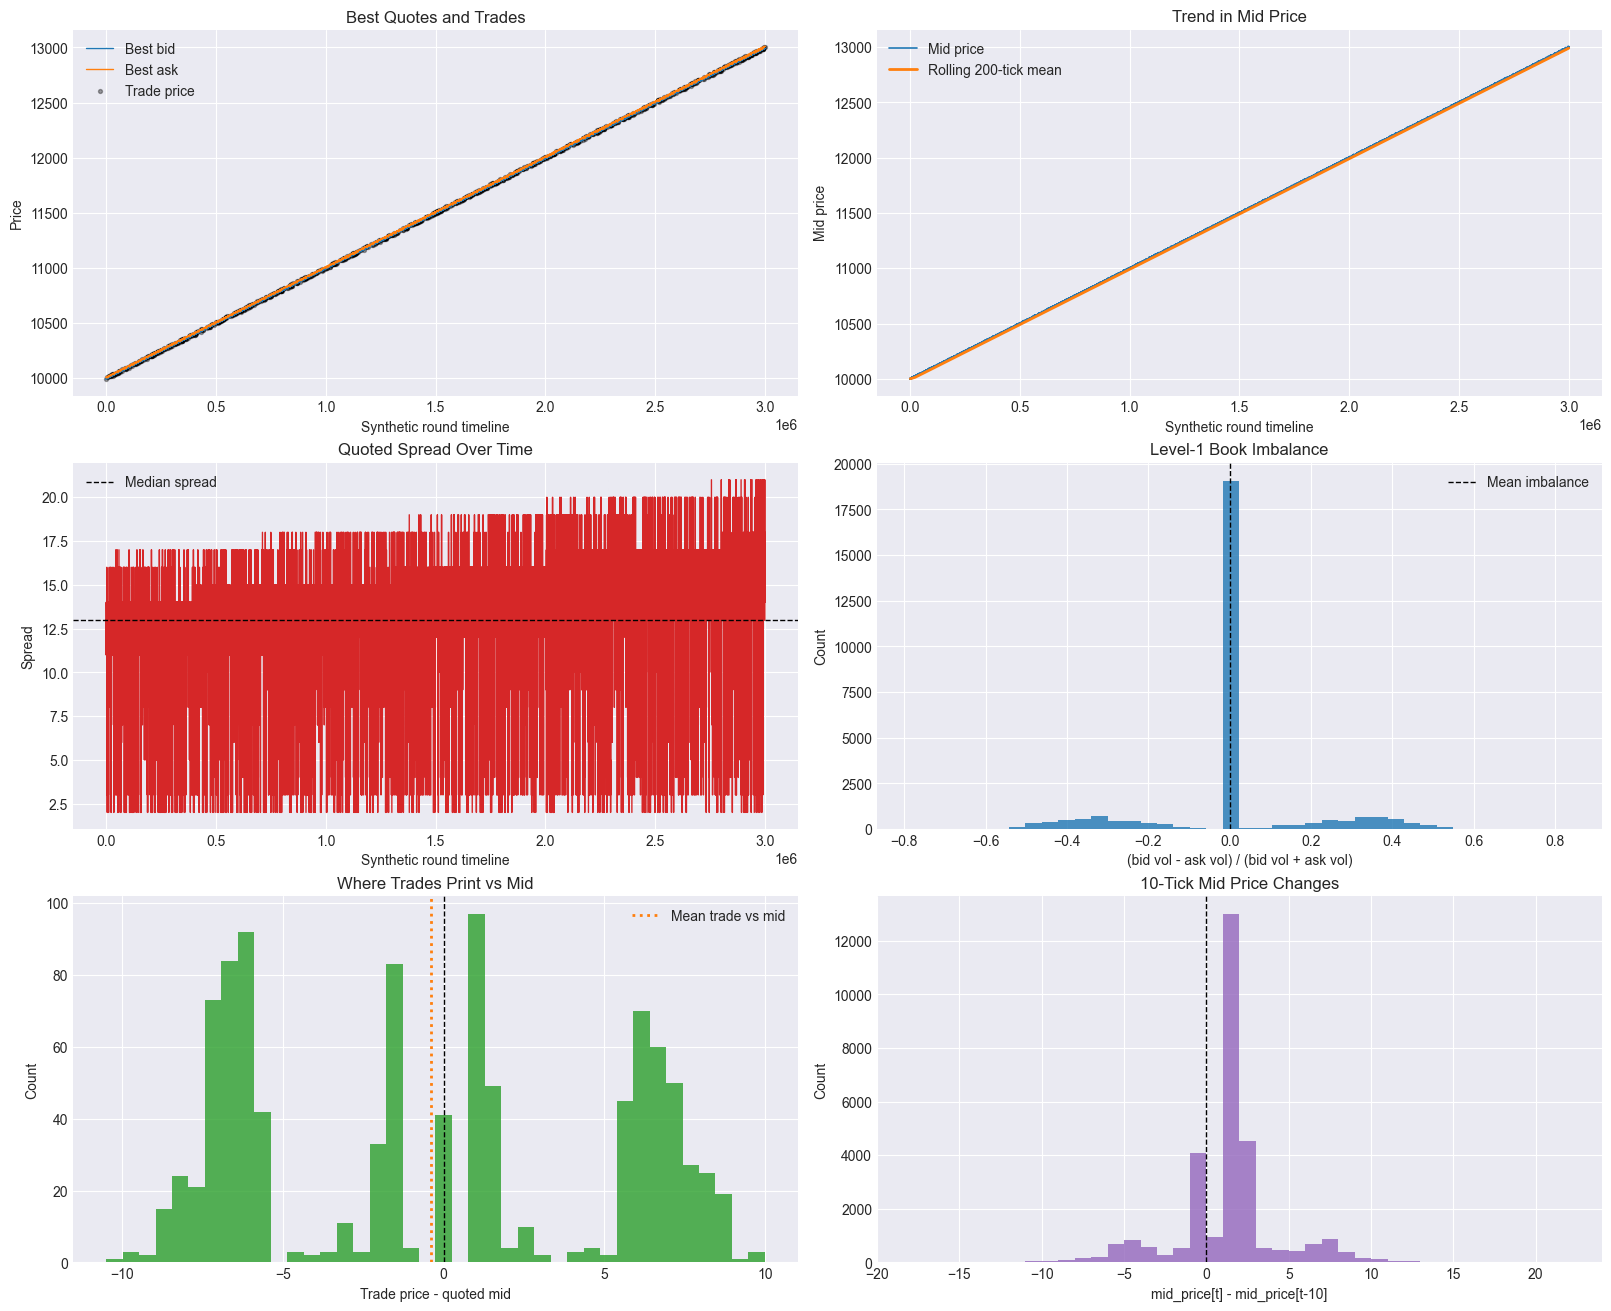

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(16, 13), constrained_layout=True)

axes[0, 0].plot(prices['global_ts'], prices['bid_price_1'], label='Best bid', linewidth=1.0)
axes[0, 0].plot(prices['global_ts'], prices['ask_price_1'], label='Best ask', linewidth=1.0)
axes[0, 0].scatter(trades['global_ts'], trades['price'], label='Trade price', s=8, alpha=0.35, color='black')
axes[0, 0].set_title('Best Quotes and Trades')
axes[0, 0].set_xlabel('Synthetic round timeline')
axes[0, 0].set_ylabel('Price')
axes[0, 0].legend()

axes[0, 1].plot(prices['global_ts'], prices['mid_price'], label='Mid price', linewidth=1.2)
axes[0, 1].plot(prices['global_ts'], prices['rolling_mid_200'], label='Rolling 200-tick mean', linewidth=2.0)
axes[0, 1].set_title('Trend in Mid Price')
axes[0, 1].set_xlabel('Synthetic round timeline')
axes[0, 1].set_ylabel('Mid price')
axes[0, 1].legend()

axes[1, 0].plot(prices['global_ts'], prices['spread_1'], color='tab:red', linewidth=1.0)
axes[1, 0].axhline(prices['spread_1'].median(), color='black', linestyle='--', linewidth=1, label='Median spread')
axes[1, 0].set_title('Quoted Spread Over Time')
axes[1, 0].set_xlabel('Synthetic round timeline')
axes[1, 0].set_ylabel('Spread')
axes[1, 0].legend()

axes[1, 1].hist(prices['book_imbalance'].dropna(), bins=40, color='tab:blue', alpha=0.8)
axes[1, 1].axvline(prices['book_imbalance'].mean(), color='black', linestyle='--', linewidth=1, label='Mean imbalance')
axes[1, 1].set_title('Level-1 Book Imbalance')
axes[1, 1].set_xlabel('(bid vol - ask vol) / (bid vol + ask vol)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()

axes[2, 0].hist(trade_context['trade_vs_mid'].dropna(), bins=40, color='tab:green', alpha=0.8)
axes[2, 0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[2, 0].axvline(trade_context['trade_vs_mid'].mean(), color='tab:orange', linestyle=':', linewidth=2, label='Mean trade vs mid')
axes[2, 0].set_title('Where Trades Print vs Mid')
axes[2, 0].set_xlabel('Trade price - quoted mid')
axes[2, 0].set_ylabel('Count')
axes[2, 0].legend()

axes[2, 1].hist(prices['mid_change_10'].dropna(), bins=40, color='tab:purple', alpha=0.8)
axes[2, 1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[2, 1].set_title('10-Tick Mid Price Changes')
axes[2, 1].set_xlabel('mid_price[t] - mid_price[t-10]')
axes[2, 1].set_ylabel('Count')

plt.show()


In [5]:
latest_quotes = prices[['day', 'timestamp', 'bid_price_1', 'bid_volume_1', 'ask_price_1', 'ask_volume_1', 'mid_price', 'spread_1']].tail(12)
largest_trades = trades[['day', 'timestamp', 'price', 'quantity', 'notional']].sort_values(['quantity', 'notional'], ascending=[False, False]).head(12)

display(latest_quotes)
display(largest_trades)


,day,timestamp,bid_price_1,bid_volume_1,ask_price_1,ask_volume_1,mid_price,spread_1
29988,0,998800,"12,992.00",8.00,"13,006.00",8.00,"12,999.00",14.00
29989,0,998900,"12,989.00",23.00,"13,006.00",8.00,"12,997.50",17.00
29990,0,999000,"12,989.00",18.00,"13,006.00",11.00,"12,997.50",17.00
29991,0,999100,"12,992.00",10.00,"13,006.00",10.00,"12,999.00",14.00
29992,0,999200,"12,992.00",9.00,"13,009.00",16.00,"13,000.50",17.00
29993,0,999300,"12,989.00",24.00,"13,010.00",24.00,"12,999.50",21.00
29994,0,999400,"12,992.00",8.00,"13,006.00",8.00,"12,999.00",14.00
29995,0,999500,"12,989.00",19.00,"13,006.00",12.00,"12,997.50",17.00
29996,0,999600,"12,993.00",8.00,"13,007.00",8.00,"13,000.00",14.00
29997,0,999700,"12,989.00",20.00,"13,007.00",10.00,"12,998.00",18.00


,day,timestamp,price,quantity,notional
1003,0,989200,"12,993.00",8,"103,944.00"
988,0,955100,"12,951.00",8,"103,608.00"
982,0,939400,"12,943.00",8,"103,544.00"
935,0,831400,"12,835.00",8,"102,680.00"
933,0,822000,"12,818.00",8,"102,544.00"
916,0,774500,"12,778.00",8,"102,224.00"
903,0,732700,"12,728.00",8,"101,824.00"
879,0,642400,"12,638.00",8,"101,104.00"
877,0,641600,"12,637.00",8,"101,096.00"
821,0,452500,"12,456.00",8,"99,648.00"


In [6]:
median_spread = prices['spread_1'].median()
mean_imbalance = prices['book_imbalance'].mean()
trade_bias_mid = trade_context['trade_vs_mid'].mean()
trade_bias_micro = trade_context['trade_vs_microprice'].mean()
up_move_1 = (prices['mid_change_1'] > 0).mean()
up_move_10 = (prices['mid_change_10'] > 0).mean()
autocorr_10 = prices['mid_price'].autocorr(10)
day0_bias_mid = trade_context.loc[trade_context['day_trade'] == 0, 'trade_vs_mid'].mean()
start_mid = prices['mid_price'].dropna().iloc[0]
end_mid = prices['mid_price'].dropna().iloc[-1]

bias_lines = [
    '## Market-Making Bias Overview',
    '',
    f'- The market trends upward strongly across the sample: mid price moves from **{start_mid:.1f}** to **{end_mid:.1f}**.',
    f'- The spread is still reasonably stable for market making: median level-1 spread is **{median_spread:.1f} ticks**.',
    f'- The book itself is not persistently one-sided: mean imbalance is **{mean_imbalance:.3f}**.',
    f'- Trend persistence is real: about **{up_move_1:.1%}** of 1-step moves and **{up_move_10:.1%}** of 10-step moves are upward, with lag-10 autocorrelation of **{autocorr_10:.3f}**.',
    f'- Trades usually print slightly below quoted fair value: **trade vs mid = {trade_bias_mid:.2f} ticks**, **trade vs microprice = {trade_bias_micro:.2f} ticks** on average.',
    f'- On day `0`, trades still print about **{day0_bias_mid:.2f} ticks** below mid on average even while the market trends up.',
    '',
    '### Practical takeaway',
    '',
    '- Use a positive directional bias in your fair-value model because the product shows continuation, not a flat stationary regime.',
    '- Keep that bias moderate rather than aggressive: the data supports leaning your fair value upward by a small amount, then letting inventory control cap the exposure.',
    '- A good default is to use a bullish drift term or momentum feature and keep your quoting center slightly above a purely static mid estimate.',
    '- Because trades often happen a little below mid even during the uptrend, you can usually bid a bit more confidently than you lift offers. In other words, skew should be **buy-leaning / upward-biased**, but not so high that you constantly chase the ask.',
    '- In live terms: trend signal sets the direction, but execution signal says do not overpay. Favor accumulating on pullbacks instead of crossing upward aggressively every time.'
]

display(Markdown('\n'.join(bias_lines)))


## Market-Making Bias Overview

- The market trends upward strongly across the sample: mid price moves from **9998.5** to **13000.0**.
- The spread is still reasonably stable for market making: median level-1 spread is **13.0 ticks**.
- The book itself is not persistently one-sided: mean imbalance is **0.001**.
- Trend persistence is real: about **37.1%** of 1-step moves and **71.8%** of 10-step moves are upward, with lag-10 autocorrelation of **1.000**.
- Trades usually print slightly below quoted fair value: **trade vs mid = -0.38 ticks**, **trade vs microprice = -0.42 ticks** on average.
- On day `0`, trades still print about **-0.36 ticks** below mid on average even while the market trends up.

### Practical takeaway

- Use a positive directional bias in your fair-value model because the product shows continuation, not a flat stationary regime.
- Keep that bias moderate rather than aggressive: the data supports leaning your fair value upward by a small amount, then letting inventory control cap the exposure.
- A good default is to use a bullish drift term or momentum feature and keep your quoting center slightly above a purely static mid estimate.
- Because trades often happen a little below mid even during the uptrend, you can usually bid a bit more confidently than you lift offers. In other words, skew should be **buy-leaning / upward-biased**, but not so high that you constantly chase the ask.
- In live terms: trend signal sets the direction, but execution signal says do not overpay. Favor accumulating on pullbacks instead of crossing upward aggressively every time.